# Solution: Exercise 01 | Unit 2 – Data Cleaning

## Instructor reference (confidential)

Complete solution for **Unit 2 - Exercise 1: Data Cleaning Practice**. Use for grading only.


## 📥 Inputs & 📤 Outputs | المدخلات والمخرجات

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

np.random.seed(42)
data = {
    'id': range(1, 201), 'name': [f'Item_{i}' for i in range(1, 201)],
    'price': np.random.uniform(10, 1000, 200), 'quantity': np.random.randint(1, 100, 200),
    'category': np.random.choice(['A', 'B', 'C', 'D'], 200), 'rating': np.random.uniform(1, 5, 200),
    'date': pd.date_range('2023-01-01', periods=200, freq='D')
}
df = pd.DataFrame(data)
df.loc[10:20, 'price'] = np.nan
df.loc[50:55, 'rating'] = np.nan
df.loc[100:105, 'quantity'] = np.nan
df = pd.concat([df, df.iloc[[0, 1, 2, 10, 11]]], ignore_index=True)
df.loc[150, 'price'] = 50000
df.loc[160, 'quantity'] = -10


### Task 1: Identify missing values

Task 1: Identify Missing Values
id           0
name         0
price       13
quantity     6
category     0
rating       6
date         0
dtype: int64


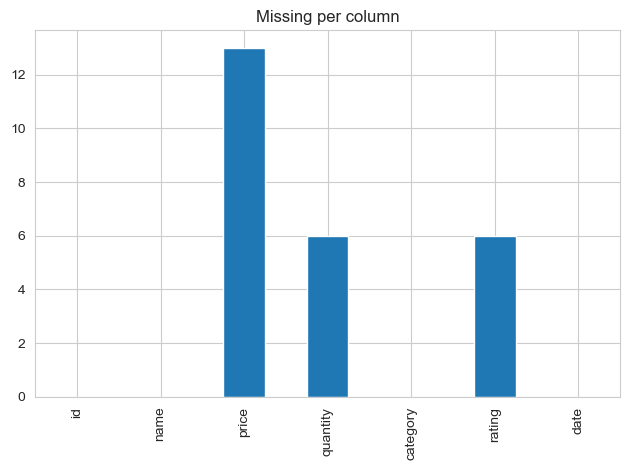

In [2]:
print("=" * 60)
print("Task 1: Identify Missing Values")
print("=" * 60)
print(df.isna().sum())
df.isna().sum().plot(kind='bar'); plt.title('Missing per column'); plt.tight_layout(); plt.show()

### Task 2: Handle missing values

In [3]:
print("\n" + "=" * 60)
print("Task 2: Handle Missing Values")
print("=" * 60)
df['price'] = df['price'].fillna(df['price'].median())
df['rating'] = df['rating'].fillna(df['rating'].mean())
df['quantity'] = df['quantity'].ffill()
print("Filled. Remaining missing:", df.isna().sum().sum())


Task 2: Handle Missing Values
Filled. Remaining missing: 0


### Task 3: Detect and remove duplicates

In [4]:
print("\n" + "=" * 60)
print("Task 3: Handle Duplicates")
print("=" * 60)
n_dup = df.duplicated().sum()
print(f"Duplicates: {n_dup}")
df = df.drop_duplicates(ignore_index=True)
print(f"After removal: {len(df)} rows")


Task 3: Handle Duplicates
Duplicates: 5
After removal: 200 rows


### Task 4: Identify outliers


Task 4: Identify Outliers
Price IQR outliers: 1
Quantity Z-score outliers (|z|>3): 0


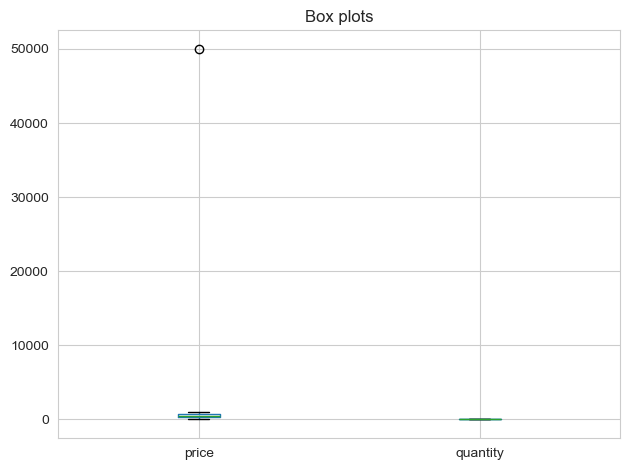

In [5]:
print("\n" + "=" * 60)
print("Task 4: Identify Outliers")
print("=" * 60)
Q1, Q3 = df['price'].quantile(0.25), df['price'].quantile(0.75)
IQR = Q3 - Q1
out_price = (df['price'] < Q1 - 1.5*IQR) | (df['price'] > Q3 + 1.5*IQR)
print(f"Price IQR outliers: {out_price.sum()}")
q_ok = df['quantity'].replace(-10, np.nan).dropna()
z = np.abs(stats.zscore(q_ok)); out_q = (z > 3).sum()
print(f"Quantity Z-score outliers (|z|>3): {out_q}")
df[['price', 'quantity']].boxplot(); plt.title('Box plots'); plt.tight_layout(); plt.show()

### Task 5: Handle outliers and invalid values

In [6]:
print("\n" + "=" * 60)
print("Task 5: Handle Outliers")
print("=" * 60)
df.loc[df['quantity'] < 0, 'quantity'] = 0
cap = Q3 + 1.5 * IQR
df.loc[df['price'] > cap, 'price'] = cap
print("Capped price, fixed negative quantity. Sample:", df[['price', 'quantity']].describe().loc[['min', 'max']])


Task 5: Handle Outliers
Capped price, fixed negative quantity. Sample:            price  quantity
min    15.466896       0.0
max  1457.875998      99.0


### Task 6: Data transformation

In [7]:
print("\n" + "=" * 60)
print("Task 6: Data Transformation")
print("=" * 60)
df['price_norm'] = (df['price'] - df['price'].min()) / (df['price'].max() - df['price'].min())
df['rating_z'] = (df['rating'] - df['rating'].mean()) / df['rating'].std()
df['total_value'] = df['price'] * df['quantity']
print(df[['price_norm', 'rating_z', 'total_value']].head())
print("\n" + "=" * 60)
print("Exercise 1 Complete!")
print("=" * 60)


Task 6: Data Transformation
   price_norm  rating_z   total_value
0    0.253276 -1.340585   9139.073224
1    0.648734 -1.397104  71340.537251
2    0.498615  0.651822  52896.528172
3    0.407100 -1.434782  21696.188377
4    0.103294  1.053365   6249.421253

Exercise 1 Complete!


---
**Teaching notes:** Check fill strategy (median/mean/ffill), correct IQR formula, and handling of invalid (e.g. negative quantity).